# Activation Functions and Optimizers for an IMDB MLP

This notebook compares six hidden activation functions and six optimizers in the existing PyTorch MLP while keeping data preparation, architecture, training budgets, and selection rules controlled.

## Experiment design

The experiment reuses the deduplicated, stratified IMDB split and training-only 20,000-feature TF-IDF representation from the earlier MLP work. Each run uses the same 128/64 architecture, batch normalization, mini-batch order, four-epoch budget, and validation-loss checkpointing.

The activation comparison holds Adam and its learning rate fixed. Initial weights follow the activation: Kaiming for LeakyReLU and PReLU, LeCun normal for SELU, and Xavier for GELU, Softplus, and Swish. The optimizer comparison then fixes the validation-selected activation and uses declared family-appropriate learning rates. These rates are not tuned, so the optimizer ranking is conditional on these practical defaults. The test set remains untouched until both choices are fixed.

## Layers and loss

The hidden stack is `Linear -> BatchNorm -> activation` twice, followed by one linear logit. Batch normalization is kept for every candidate so the nonlinear mapping is the main architectural change; the experiment does not test SELU's separate self-normalizing recipe.

`BCEWithLogitsLoss` combines the sigmoid transformation and binary cross-entropy in a numerically stable operation. A separate sigmoid is used only when converting final logits to probabilities for metrics.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
import torch
from torch import nn

SEED = 42
EPOCHS = 4
BATCH_SIZE = 512
GRADIENT_NORM_CEILING = 1.0

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_name = "Not detected"
if shutil.which("nvidia-smi"):
    query = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True,
        text=True,
        check=True,
    )
    gpu_name = query.stdout.strip()

current_path = Path.cwd().resolve()
repository_root = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "phase-1-machine-learning-nlp").is_dir()
    ),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

phase_1 = repository_root / "phase-1-machine-learning-nlp"
part_02 = phase_1 / "02-preprocessing-tokenization"
part_06 = phase_1 / "06-vectorization"
sys.path.insert(0, str(part_02 / "src"))
sys.path.insert(0, str(part_06 / "src"))

from preprocessor import preprocess_text
from tokenizer import regex_tokenize
from vectorizer import CustomTfidfVectorizer

imdb_path = part_02 / "data" / "IMDB Dataset.csv"
if not imdb_path.exists():
    raise FileNotFoundError(
        "Download the IMDB 50K Reviews dataset and place 'IMDB Dataset.csv' in "
        f"{imdb_path.parent}. The CSV is intentionally ignored by Git."
    )

imdb = pd.read_csv(imdb_path)
required_columns = {"review", "sentiment"}
if not required_columns.issubset(imdb.columns):
    raise KeyError(f"The IMDB dataset must contain {sorted(required_columns)}.")
imdb = imdb.dropna(subset=["review", "sentiment"])
imdb["label"] = imdb["sentiment"].map({"negative": 0, "positive": 1})
if imdb["label"].isna().any():
    raise ValueError("Sentiment labels must be either 'negative' or 'positive'.")

def model_visible_text(review):
    cleaned = preprocess_text(
        str(review), remove_stopwords=False, apply_stemming=False
    )
    return " ".join(
        token
        for token in regex_tokenize(cleaned)
        if token.isalpha() and len(token) >= 2
    )


imdb["model_visible_text"] = imdb["review"].map(model_visible_text)
if imdb["model_visible_text"].eq("").any():
    raise ValueError("Preprocessing produced an empty review.")
if imdb.groupby("model_visible_text")["label"].nunique().gt(1).any():
    raise ValueError("Reviews identical after preprocessing have conflicting labels.")
original_size = len(imdb)
imdb = imdb.drop_duplicates(subset="model_visible_text").reset_index(drop=True)

development, test = train_test_split(
    imdb,
    test_size=0.20,
    random_state=SEED,
    stratify=imdb["label"],
)
train, validation = train_test_split(
    development,
    test_size=0.25,
    random_state=SEED,
    stratify=development["label"],
)

split_frames = {"train": train, "validation": validation, "test": test}
for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
    assert set(split_frames[left]["model_visible_text"]).isdisjoint(
        split_frames[right]["model_visible_text"]
    )

X_train, y_train = train["review"], train["label"]
X_validation, y_validation = validation["review"], validation["label"]
X_test, y_test = test["review"], test["label"]

split_summary = pd.DataFrame(
    {
        "reviews": [len(X_train), len(X_validation), len(X_test)],
        "positive proportion": [y_train.mean(), y_validation.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)

print(f"PyTorch: {torch.__version__}")
print(f"System GPU: {gpu_name}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Selected device: {device}")
print(f"Reviews retained: {len(imdb):,} ({original_size - len(imdb):,} duplicates removed)")
print("Model-visible review overlap across splits: 0")
display(split_summary.style.format({"positive proportion": "{:.4f}"}))

PyTorch: 2.13.0+cpu
System GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
PyTorch CUDA available: False
Selected device: cpu
Reviews retained: 49,580 (420 duplicates removed)
Model-visible review overlap across splits: 0


,reviews,positive proportion
train,29748,0.5019
validation,9916,0.5019
test,9916,0.5019


In [2]:
vectorizer = CustomTfidfVectorizer(
    preprocessor=preprocess_text,
    tokenizer=regex_tokenize,
    min_df=5,
    max_df=0.95,
    max_features=20_000,
)
input_normalizer = Normalizer(norm="l2", copy=False)

vectorization_start = time.perf_counter()
X_train_tfidf = input_normalizer.fit_transform(
    vectorizer.fit_transform(X_train)
).astype(np.float32)
X_validation_tfidf = input_normalizer.transform(
    vectorizer.transform(X_validation)
).astype(np.float32)
X_test_tfidf = input_normalizer.transform(
    vectorizer.transform(X_test)
).astype(np.float32)
vectorization_seconds = time.perf_counter() - vectorization_start

y_train_array = y_train.to_numpy(dtype=np.float32)
y_validation_array = y_validation.to_numpy(dtype=np.float32)
y_test_array = y_test.to_numpy(dtype=np.float32)
train_norms = np.sqrt(X_train_tfidf.multiply(X_train_tfidf).sum(axis=1)).A1
nonzero_norms = train_norms[train_norms > 0]
density = X_train_tfidf.nnz / np.prod(X_train_tfidf.shape)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Training matrix density: {density:.4%}")
print(f"Mean non-empty training-row L2 norm: {nonzero_norms.mean():.6f}")
print(f"Vectorization time: {vectorization_seconds:.2f} seconds")
assert np.allclose(nonzero_norms, 1.0, atol=1e-5)

Vocabulary size: 20,000
Training matrix shape: (29748, 20000)
Training matrix density: 0.6252%
Mean non-empty training-row L2 norm: 1.000000
Vectorization time: 17.92 seconds


## Controlled training functions

Every candidate starts from the same seed and receives the same per-epoch shuffle. Gradient clipping and finite-value checks make divergent runs explicit. The best checkpoint within each run is selected by validation loss.

In [3]:
activation_names = [
    "LeakyReLU",
    "PReLU",
    "SELU",
    "GELU",
    "Softplus",
    "Swish",
]

def build_activation(name):
    if name == "LeakyReLU":
        return nn.LeakyReLU(negative_slope=0.01)
    if name == "PReLU":
        return nn.PReLU(num_parameters=1, init=0.25)
    if name == "SELU":
        return nn.SELU()
    if name == "GELU":
        return nn.GELU()
    if name == "Softplus":
        return nn.Softplus()
    if name == "Swish":
        return nn.SiLU()
    raise KeyError(f"Unknown activation: {name}")


def initialize_hidden(layer, activation_name):
    if activation_name == "LeakyReLU":
        nn.init.kaiming_normal_(
            layer.weight, a=0.01, nonlinearity="leaky_relu"
        )
    elif activation_name == "PReLU":
        nn.init.kaiming_normal_(
            layer.weight, a=0.25, nonlinearity="leaky_relu"
        )
    elif activation_name == "SELU":
        nn.init.normal_(layer.weight, mean=0.0, std=layer.in_features ** -0.5)
    else:
        nn.init.xavier_normal_(layer.weight)
    nn.init.zeros_(layer.bias)


class ActivationSentimentMLP(nn.Module):
    def __init__(self, input_features, activation_name):
        super().__init__()
        self.hidden_1 = nn.Linear(input_features, 128)
        self.normalization_1 = nn.BatchNorm1d(128)
        self.activation_1 = build_activation(activation_name)
        self.hidden_2 = nn.Linear(128, 64)
        self.normalization_2 = nn.BatchNorm1d(64)
        self.activation_2 = build_activation(activation_name)
        self.output = nn.Linear(64, 1)
        initialize_hidden(self.hidden_1, activation_name)
        initialize_hidden(self.hidden_2, activation_name)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, features):
        if features.is_sparse:
            hidden = torch.sparse.mm(features, self.hidden_1.weight.T)
            hidden = hidden + self.hidden_1.bias
        else:
            hidden = self.hidden_1(features)
        hidden = self.activation_1(self.normalization_1(hidden))
        hidden = self.activation_2(self.normalization_2(self.hidden_2(hidden)))
        return self.output(hidden).squeeze(1)


loss_function = nn.BCEWithLogitsLoss()

def reset_seed():
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


def to_sparse_batch(matrix, indices):
    batch = matrix[indices].tocoo()
    coordinates = np.vstack((batch.row, batch.col)).astype(np.int64)
    return torch.sparse_coo_tensor(
        torch.from_numpy(coordinates),
        torch.from_numpy(batch.data),
        size=batch.shape,
        device=device,
        check_invariants=False,
    ).coalesce()


def evaluate_model(model, matrix, labels):
    model.eval()
    total_loss = 0.0
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(labels), BATCH_SIZE):
            indices = np.arange(start, min(start + BATCH_SIZE, len(labels)))
            features = to_sparse_batch(matrix, indices)
            targets = torch.from_numpy(labels[indices]).to(device)
            logits = model(features)
            loss = loss_function(logits, targets)
            if not torch.isfinite(loss):
                raise FloatingPointError("Evaluation produced a non-finite loss.")
            total_loss += loss.item() * len(indices)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return total_loss / len(labels), np.concatenate(probabilities)


def state_on_cpu(model):
    return {
        name: value.detach().cpu().clone()
        for name, value in model.state_dict().items()
    }


def build_optimizer(name, parameters, learning_rate):
    if name == "SGD":
        return torch.optim.SGD(parameters, lr=learning_rate)
    if name == "SGD with momentum":
        return torch.optim.SGD(
            parameters, lr=learning_rate, momentum=0.9
        )
    if name == "SGD with Nesterov momentum":
        return torch.optim.SGD(
            parameters,
            lr=learning_rate,
            momentum=0.9,
            nesterov=True,
        )
    if name == "Adam":
        return torch.optim.Adam(parameters, lr=learning_rate)
    if name == "RMSProp":
        return torch.optim.RMSprop(
            parameters, lr=learning_rate, alpha=0.99
        )
    if name == "AMSGrad":
        return torch.optim.Adam(
            parameters, lr=learning_rate, amsgrad=True
        )
    raise KeyError(f"Unknown optimizer: {name}")


def train_and_select(activation_name, optimizer_name, learning_rate):
    reset_seed()
    model = ActivationSentimentMLP(
        X_train_tfidf.shape[1], activation_name
    ).to(device)
    optimizer = build_optimizer(
        optimizer_name, model.parameters(), learning_rate
    )
    history = []
    best_state = None
    best_validation_loss = float("inf")
    best_epoch = None
    maximum_gradient_norm = 0.0
    clipped_updates = 0
    run_start = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_training_loss = 0.0
        shuffled_indices = np.random.default_rng(SEED + epoch).permutation(
            len(y_train_array)
        )
        for start in range(0, len(y_train_array), BATCH_SIZE):
            indices = shuffled_indices[start:start + BATCH_SIZE]
            features = to_sparse_batch(X_train_tfidf, indices)
            targets = torch.from_numpy(y_train_array[indices]).to(device)
            optimizer.zero_grad()
            logits = model(features)
            loss = loss_function(logits, targets)
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"{activation_name} with {optimizer_name} produced a non-finite loss."
                )
            loss.backward()
            gradient_norm = float(torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRADIENT_NORM_CEILING,
                error_if_nonfinite=True,
            ))
            maximum_gradient_norm = max(maximum_gradient_norm, gradient_norm)
            clipped_updates += int(gradient_norm > GRADIENT_NORM_CEILING)
            optimizer.step()
            total_training_loss += loss.item() * len(indices)

        training_loss = total_training_loss / len(y_train_array)
        validation_loss, validation_probabilities = evaluate_model(
            model, X_validation_tfidf, y_validation_array
        )
        validation_predictions = (validation_probabilities >= 0.5).astype(int)
        row = {
            "epoch": epoch,
            "train loss": training_loss,
            "validation loss": validation_loss,
            "validation accuracy": accuracy_score(
                y_validation_array, validation_predictions
            ),
            "validation F1": f1_score(
                y_validation_array, validation_predictions
            ),
        }
        history.append(row)
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = state_on_cpu(model)

    history_frame = pd.DataFrame(history).set_index("epoch")
    best_row = history_frame.loc[best_epoch]
    summary = {
        "activation": activation_name,
        "optimizer": optimizer_name,
        "learning rate": learning_rate,
        "best epoch": best_epoch,
        "validation loss": best_validation_loss,
        "validation accuracy": best_row["validation accuracy"],
        "validation F1": best_row["validation F1"],
        "maximum gradient norm": maximum_gradient_norm,
        "clipped updates": clipped_updates,
        "seconds": time.perf_counter() - run_start,
    }
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return best_state, history_frame, summary

## Activation comparison

All six activation functions use Adam at `1e-3`. The minimum validation loss decides the winner; validation accuracy and F1 provide complementary classification views.

LeakyReLU  | best epoch 2 | validation loss 0.2835 | validation F1 0.8896


PReLU      | best epoch 2 | validation loss 0.3070 | validation F1 0.8856


SELU       | best epoch 2 | validation loss 0.3227 | validation F1 0.8812


GELU       | best epoch 2 | validation loss 0.2859 | validation F1 0.8876


Softplus   | best epoch 2 | validation loss 0.2959 | validation F1 0.8854


Swish      | best epoch 2 | validation loss 0.2953 | validation F1 0.8853


,activation,optimizer,learning rate,best epoch,validation loss,validation accuracy,validation F1,maximum gradient norm,clipped updates,seconds
0,LeakyReLU,Adam,1.0e-03,2,0.2835,0.8884,0.8896,3.1292,23,18.45
3,GELU,Adam,1.0e-03,2,0.2859,0.8857,0.8876,2.9082,17,17.88
5,Swish,Adam,1.0e-03,2,0.2953,0.8834,0.8853,2.6335,11,18.44
4,Softplus,Adam,1.0e-03,2,0.2959,0.8828,0.8854,2.5989,9,18.17
1,PReLU,Adam,1.0e-03,2,0.3070,0.8834,0.8856,3.3147,16,18.45
2,SELU,Adam,1.0e-03,2,0.3227,0.8793,0.8812,6.8982,19,18.50


Selected activation: LeakyReLU


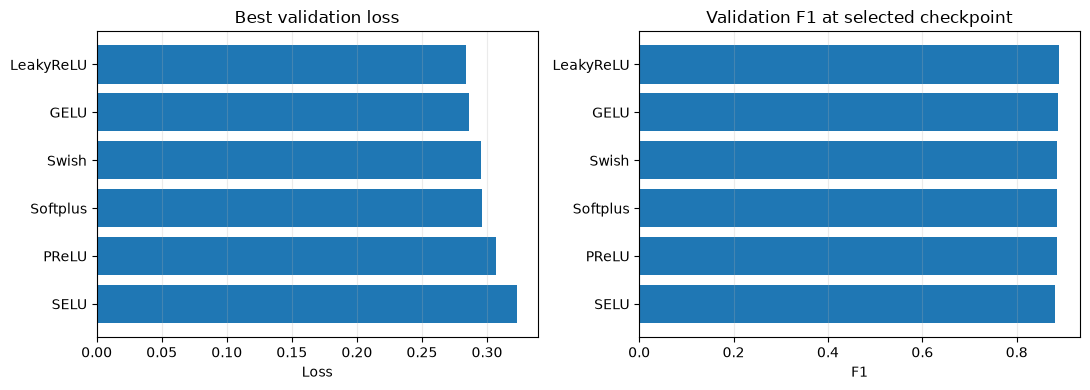

In [4]:
activation_states = {}
activation_histories = {}
activation_summaries = []

for activation_name in activation_names:
    state, history, summary = train_and_select(
        activation_name=activation_name,
        optimizer_name="Adam",
        learning_rate=1e-3,
    )
    activation_states[activation_name] = state
    activation_histories[activation_name] = history
    activation_summaries.append(summary)
    print(
        f"{activation_name:<10} | best epoch {summary['best epoch']} | "
        f"validation loss {summary['validation loss']:.4f} | "
        f"validation F1 {summary['validation F1']:.4f}"
    )

activation_results = pd.DataFrame(activation_summaries).sort_values(
    "validation loss"
)
best_activation = activation_results.iloc[0]["activation"]

display(activation_results.style.format({
    "learning rate": "{:.1e}",
    "validation loss": "{:.4f}",
    "validation accuracy": "{:.4f}",
    "validation F1": "{:.4f}",
    "maximum gradient norm": "{:.4f}",
    "seconds": "{:.2f}",
}))
print(f"Selected activation: {best_activation}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_order = activation_results.sort_values("validation loss", ascending=False)
axes[0].barh(plot_order["activation"], plot_order["validation loss"])
axes[1].barh(plot_order["activation"], plot_order["validation F1"])
axes[0].set_title("Best validation loss")
axes[1].set_title("Validation F1 at selected checkpoint")
axes[0].set_xlabel("Loss")
axes[1].set_xlabel("F1")
for axis in axes:
    axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Optimizer comparison

The selected activation is now fixed. SGD uses `0.1`; momentum and Nesterov variants use `0.05`; Adam, RMSProp, and AMSGrad use `1e-3`. Momentum is `0.9`, Nesterov acceleration is enabled only for its named candidate, RMSProp uses decay `0.99`, and AMSGrad uses Adam's maximum-second-moment variant.

SGD                         | best epoch 2 | validation loss 0.3012 | validation F1 0.8716


SGD with momentum           | best epoch 2 | validation loss 0.3103 | validation F1 0.8834


SGD with Nesterov momentum  | best epoch 2 | validation loss 0.3125 | validation F1 0.8829


Adam                        | best epoch 2 | validation loss 0.2835 | validation F1 0.8896


RMSProp                     | best epoch 1 | validation loss 0.2817 | validation F1 0.8899


AMSGrad                     | best epoch 2 | validation loss 0.2834 | validation F1 0.8898


,activation,optimizer,learning rate,best epoch,validation loss,validation accuracy,validation F1,maximum gradient norm,clipped updates,seconds
4,LeakyReLU,RMSProp,1.0e-03,1,0.2817,0.8916,0.8899,3.1292,4,17.53
5,LeakyReLU,AMSGrad,1.0e-03,2,0.2834,0.8884,0.8898,3.1292,23,19.17
3,LeakyReLU,Adam,1.0e-03,2,0.2835,0.8884,0.8896,3.1292,23,19.31
0,LeakyReLU,SGD,1.0e-01,2,0.3012,0.8691,0.8716,5.2652,130,17.13
1,LeakyReLU,SGD with momentum,5.0e-02,2,0.3103,0.8815,0.8834,3.8548,60,15.88
2,LeakyReLU,SGD with Nesterov momentum,5.0e-02,2,0.3125,0.8812,0.8829,4.0828,60,16.63


Selected optimizer: RMSProp at 1.0e-03


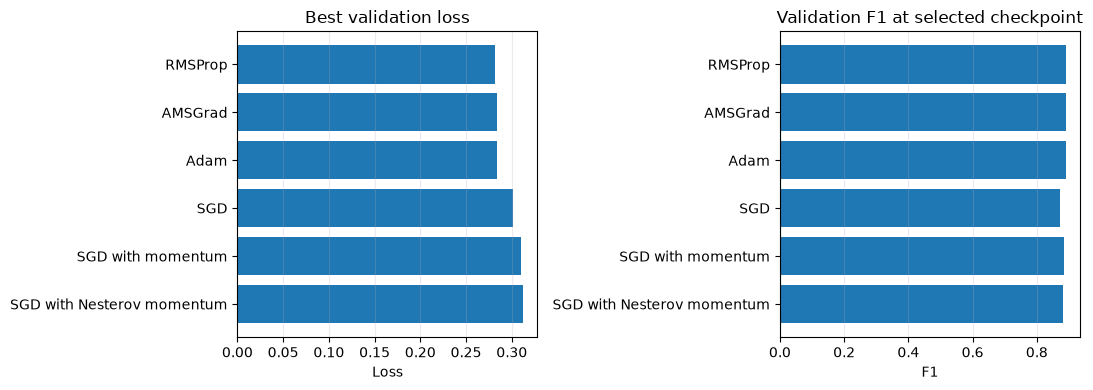

In [5]:
optimizer_settings = {
    "SGD": 0.1,
    "SGD with momentum": 0.05,
    "SGD with Nesterov momentum": 0.05,
    "Adam": 1e-3,
    "RMSProp": 1e-3,
    "AMSGrad": 1e-3,
}

optimizer_states = {}
optimizer_histories = {}
optimizer_summaries = []

for optimizer_name, learning_rate in optimizer_settings.items():
    state, history, summary = train_and_select(
        activation_name=best_activation,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
    )
    optimizer_states[optimizer_name] = state
    optimizer_histories[optimizer_name] = history
    optimizer_summaries.append(summary)
    print(
        f"{optimizer_name:<27} | best epoch {summary['best epoch']} | "
        f"validation loss {summary['validation loss']:.4f} | "
        f"validation F1 {summary['validation F1']:.4f}"
    )

optimizer_results = pd.DataFrame(optimizer_summaries).sort_values(
    "validation loss"
)
best_optimizer = optimizer_results.iloc[0]["optimizer"]
best_learning_rate = float(optimizer_results.iloc[0]["learning rate"])
final_state = optimizer_states[best_optimizer]

display(optimizer_results.style.format({
    "learning rate": "{:.1e}",
    "validation loss": "{:.4f}",
    "validation accuracy": "{:.4f}",
    "validation F1": "{:.4f}",
    "maximum gradient norm": "{:.4f}",
    "seconds": "{:.2f}",
}))
print(f"Selected optimizer: {best_optimizer} at {best_learning_rate:.1e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_order = optimizer_results.sort_values("validation loss", ascending=False)
axes[0].barh(plot_order["optimizer"], plot_order["validation loss"])
axes[1].barh(plot_order["optimizer"], plot_order["validation F1"])
axes[0].set_title("Best validation loss")
axes[1].set_title("Validation F1 at selected checkpoint")
axes[0].set_xlabel("Loss")
axes[1].set_xlabel("F1")
for axis in axes:
    axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Held-out evaluation

The activation and optimizer are fixed from validation results. Only their retained checkpoint is evaluated on the test set.

,test score
loss,0.2854
accuracy,0.8903
precision,0.9064
recall,0.8714
F1,0.8885
ROC AUC,0.9573


Final model: LeakyReLU with RMSProp at learning rate 1.0e-03
              precision    recall  f1-score   support

    negative     0.8753    0.9093    0.8920      4939
    positive     0.9064    0.8714    0.8885      4977

    accuracy                         0.8903      9916
   macro avg     0.8908    0.8904    0.8903      9916
weighted avg     0.8909    0.8903    0.8902      9916



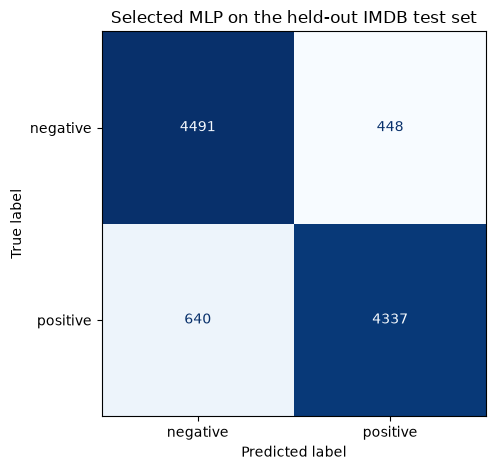

In [6]:
final_model = ActivationSentimentMLP(
    X_train_tfidf.shape[1], best_activation
).to(device)
final_model.load_state_dict(final_state)
test_loss, test_probabilities = evaluate_model(
    final_model, X_test_tfidf, y_test_array
)
test_predictions = (test_probabilities >= 0.5).astype(int)
test_metrics = pd.Series(
    {
        "loss": test_loss,
        "accuracy": accuracy_score(y_test_array, test_predictions),
        "precision": precision_score(y_test_array, test_predictions),
        "recall": recall_score(y_test_array, test_predictions),
        "F1": f1_score(y_test_array, test_predictions),
        "ROC AUC": roc_auc_score(y_test_array, test_probabilities),
    },
    name="test score",
).to_frame()

display(test_metrics.style.format("{:.4f}"))
print(
    f"Final model: {best_activation} with {best_optimizer} "
    f"at learning rate {best_learning_rate:.1e}"
)
print(classification_report(
    y_test_array,
    test_predictions,
    target_names=["negative", "positive"],
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    y_test_array,
    test_predictions,
    display_labels=["negative", "positive"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Selected MLP on the held-out IMDB test set")
plt.tight_layout()
plt.show()

assert np.isfinite(test_metrics.to_numpy()).all()
assert len(test_predictions) == len(y_test_array)

In [7]:
activation_winner = activation_results.iloc[0]
activation_runner_up = activation_results.iloc[1]
optimizer_winner = optimizer_results.iloc[0]
total_experiment_seconds = (
    activation_results["seconds"].sum()
    + optimizer_results["seconds"].sum()
)

display(Markdown(
    f'''## Observations

**{best_activation}** produced the lowest activation-comparison validation loss at **{activation_winner['validation loss']:.4f}**, with validation F1 **{activation_winner['validation F1']:.4f}**. The runner-up was **{activation_runner_up['activation']}** at validation loss **{activation_runner_up['validation loss']:.4f}**. This is a close, budget-specific result rather than a universal ranking of activation functions.

With {best_activation} fixed, **{best_optimizer}** at learning rate **{best_learning_rate:.1e}** gave the lowest optimizer-comparison validation loss, **{optimizer_winner['validation loss']:.4f}**, and validation F1 **{optimizer_winner['validation F1']:.4f}**. Different fixed learning rates or longer training could change the optimizer order, especially for SGD-family methods.

The validation-selected final checkpoint achieved held-out accuracy **{test_metrics.loc['accuracy', 'test score']:.4f}**, precision **{test_metrics.loc['precision', 'test score']:.4f}**, recall **{test_metrics.loc['recall', 'test score']:.4f}**, F1 **{test_metrics.loc['F1', 'test score']:.4f}**, and ROC AUC **{test_metrics.loc['ROC AUC', 'test score']:.4f}**.

All runs remained finite. The two comparison stages trained in **{total_experiment_seconds:.2f} seconds** after **{vectorization_seconds:.2f} seconds** of vectorization. The detected system GPU was **{gpu_name}**, but CUDA availability was **{torch.cuda.is_available()}**, so the experiment used **{device}**.'''
))

## Observations

**LeakyReLU** produced the lowest activation-comparison validation loss at **0.2835**, with validation F1 **0.8896**. The runner-up was **GELU** at validation loss **0.2859**. This is a close, budget-specific result rather than a universal ranking of activation functions.

With LeakyReLU fixed, **RMSProp** at learning rate **1.0e-03** gave the lowest optimizer-comparison validation loss, **0.2817**, and validation F1 **0.8899**. Different fixed learning rates or longer training could change the optimizer order, especially for SGD-family methods.

The validation-selected final checkpoint achieved held-out accuracy **0.8903**, precision **0.9064**, recall **0.8714**, F1 **0.8885**, and ROC AUC **0.9573**.

All runs remained finite. The two comparison stages trained in **215.54 seconds** after **17.92 seconds** of vectorization. The detected system GPU was **NVIDIA GeForce RTX 3050 Ti Laptop GPU**, but CUDA availability was **False**, so the experiment used **cpu**.